In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../dados/brutos/pesquisa_salarial_2024.csv")

In [3]:
df_salario = df[df["ConvertedCompYearly"].notna()].copy()
df_salario.shape

(23435, 114)

In [4]:
colunas_relevantes = [
    "Country",
    "YearsCodePro",
    "DevType",
    "EdLevel",
    "RemoteWork",
    "OrgSize",
    "Employment",
    "ConvertedCompYearly"
]

df_salario = df_salario[colunas_relevantes]
df_salario.head()

,Country,YearsCodePro,DevType,EdLevel,RemoteWork,OrgSize,Employment,ConvertedCompYearly
72,Pakistan,1,Data scientist or machine learning specialist,"Secondary school (e.g. American high school, G...","Hybrid (some remote, some in-person)",100 to 499 employees,"Employed, full-time;Student, full-time;Indepen...",7322.0
374,Austria,6,Academic researcher,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Hybrid (some remote, some in-person)",100 to 499 employees,"Employed, full-time",30074.0
379,Turkey,6,Data scientist or machine learning specialist,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Remote,20 to 99 employees,"Employed, full-time",91295.0
385,France,17,"Developer, back-end","Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Remote,"Just me - I am a freelancer, sole proprietor, ...","Independent contractor, freelancer, or self-em...",53703.0
389,United States of America,7,Student,Some college/university study without earning ...,Remote,10 to 19 employees,"Employed, full-time;Student, part-time",110000.0


In [5]:
df_salario.isna().sum()

Country                 0
YearsCodePro           90
DevType                32
EdLevel                 0
RemoteWork              8
OrgSize                25
Employment              0
ConvertedCompYearly     0
dtype: int64

In [6]:
df_salario = df_salario[df_salario["Employment"] == "Employed, full-time"]
df_salario.shape

(17586, 8)

In [7]:
def limpar_anos_experiencia(valor):
    if pd.isna(valor):
        return np.nan
    if valor == "Less than 1 year":
        return 0
    if valor == "More than 50 years":
        return 51
    return float(valor)

df_salario["YearsCodePro"] = df_salario["YearsCodePro"].apply(limpar_anos_experiencia)

In [8]:
df_salario = df_salario.dropna(subset=["YearsCodePro"])
df_salario.shape

(17527, 8)

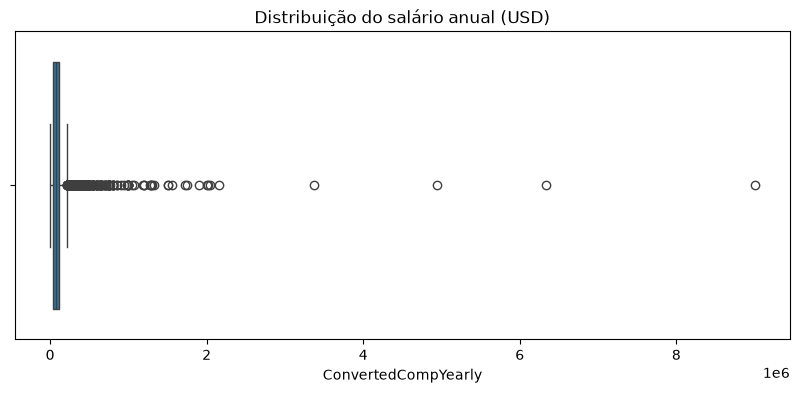

In [9]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_salario["ConvertedCompYearly"])
plt.title("Distribuição do salário anual (USD)")
plt.show()

In [10]:
limite_inferior = df_salario["ConvertedCompYearly"].quantile(0.01)
limite_superior = df_salario["ConvertedCompYearly"].quantile(0.99)

df_salario = df_salario[
    (df_salario["ConvertedCompYearly"] >= limite_inferior) &
    (df_salario["ConvertedCompYearly"] <= limite_superior)
]
df_salario.shape

(17203, 8)

In [11]:
df_salario = df_salario.dropna(subset=["DevType"])
df_salario["DevType"] = df_salario["DevType"].apply(lambda x: x.split(";")[0])
df_salario["DevType"].value_counts().head(10)

DevType
Developer, full-stack                            5970
Developer, back-end                              3661
Developer, front-end                             1053
Developer, desktop or enterprise applications     809
Developer, embedded applications or devices       610
Developer, mobile                                 570
Other (please specify):                           465
Engineering manager                               446
Data engineer                                     435
DevOps specialist                                 356
Name: count, dtype: int64

In [12]:
df_salario["RemoteWork"] = df_salario["RemoteWork"].fillna("Não informado")
df_salario["EdLevel"] = df_salario["EdLevel"].fillna("Não informado")
df_salario["OrgSize"] = df_salario["OrgSize"].fillna("Não informado")

In [13]:
df_salario.isna().sum()
df_salario.shape

(17182, 8)

In [14]:
df_salario.to_csv("../dados/processados/dados_tratados.csv", index=False)